# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Dataset

In [2]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# Exploratory Data Analysis (EDA)

**Distribution of the target**

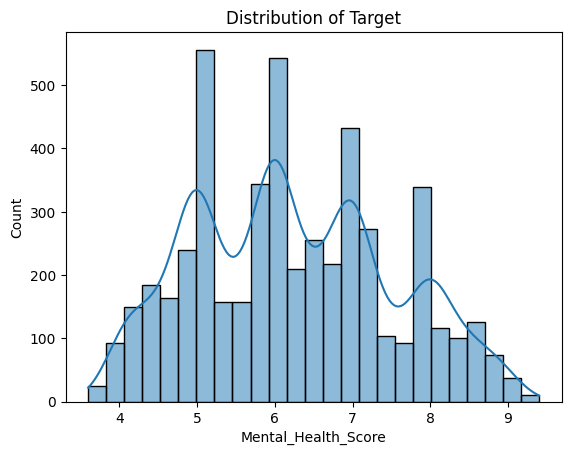

In [9]:
sns.histplot(df['Mental_Health_Score'],kde=True)
plt.title("Distribution of Target")
plt.show()

**Correlation Heatmap**

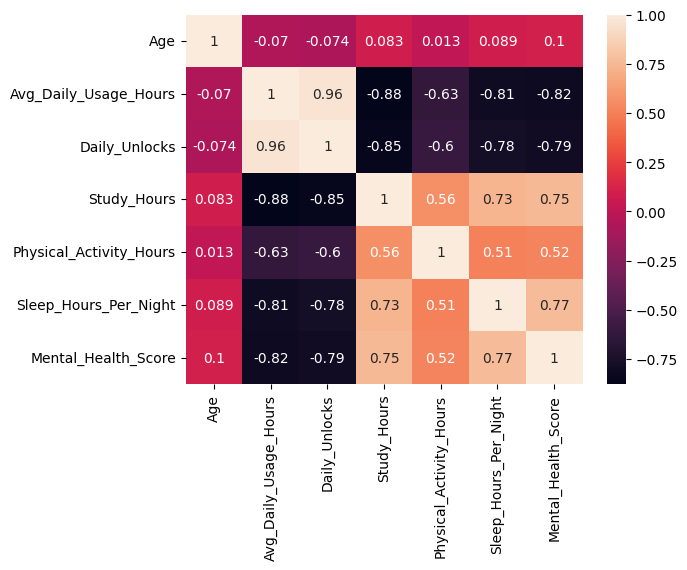

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

**Stress Level vs Mental Health Score**

In [11]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

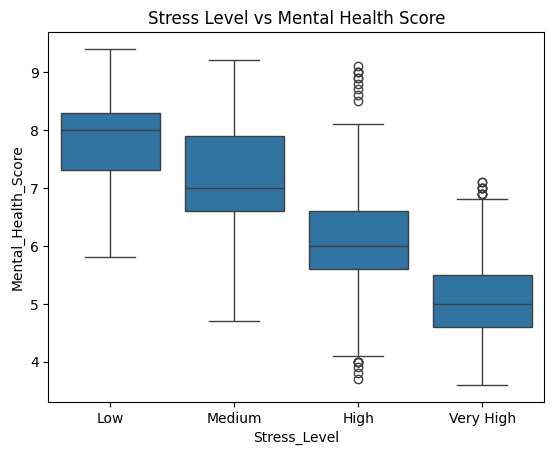

In [12]:
order=['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)
plt.title("Stress Level vs Mental Health Score")
plt.show()

**Daily Usage Hours vs Mental Health Score**

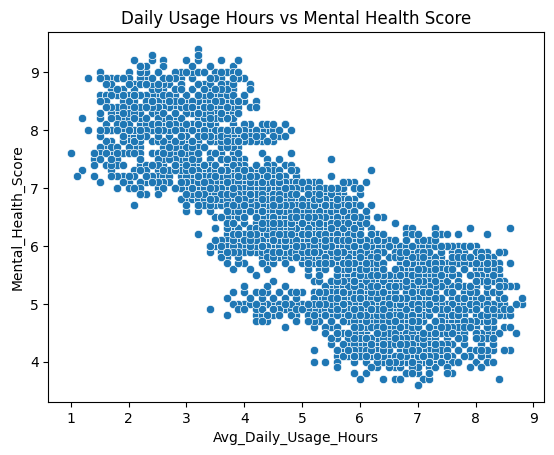

In [13]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)
plt.title("Daily Usage Hours vs Mental Health Score")
plt.show()

**Sleep Hours vs Mental Health Score**

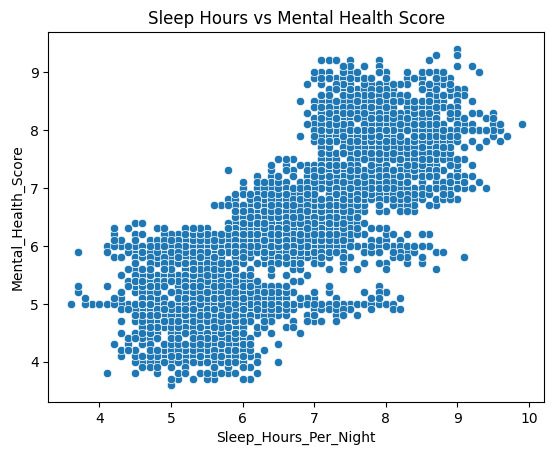

In [14]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)
plt.title("Sleep Hours vs Mental Health Score")
plt.show()

**Most Used Platform**

In [15]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


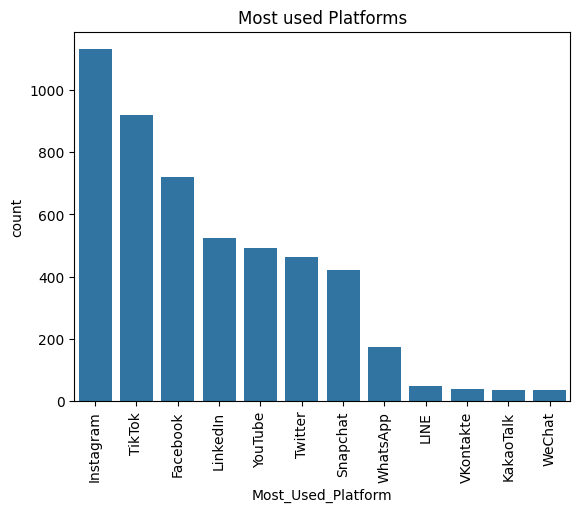

In [16]:
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Most used Platforms")
plt.show()

**Checking Outliers**

In [17]:
num_features=df.select_dtypes(include='number')
Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=(num_features<lower_bound)|(num_features>upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# Data Cleaning

**Droping Duplicates**

In [18]:
df=df.drop_duplicates()

In [19]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

# Skewnesss

num near to 0 -> Centralized

num negative -> Left Skewed

num positive -> Right Skewed

In [20]:
num_cols=df.select_dtypes(include='number')
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


# Feature Engineering

In [21]:
top_10_countries=df['Country'].value_counts().index[:10].to_list()

In [22]:
top_10_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [23]:
def group_country(country):
  if country in top_10_countries:
    return country
  else:
    return "Other"

In [24]:
df['Groupped_Country']=df['Country'].apply(group_country)

In [25]:
df['Groupped_Country'].value_counts()

,count
Groupped_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


# Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
skewed_cols=["Study_Hours"]
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_cols=["Stress_Level"]
normal_cols=["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Groupped_Country"]

featured_cols=skewed_cols+other_numeric_cols+ordinal_cols+normal_cols
x=df[featured_cols]
Y=df['Mental_Health_Score']

x_train,x_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.3,random_state=42)

# Preprocessing using Column Transformer

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

1. We are performing **Log Transformation** on **"Study_Hours"** to reduce its skewness and then applying **Standard Scaler** on it

2. We are performing **Standard Scaler** on other numeric columns

3. We are applying **Ordinal Encoding** on **"Stress_Level"** to maintain its order **[1.Low, 2.Medium, 3.High, 4.Very High]**

4. Lastly we are performing **OneHot Encoding** on other categorical columns because maintaining order is not necesary here

In [29]:
# skewed features pipeline
skewed_pipeline=Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p))
])

# numeric features pipeline
numerical_pipeline=Pipeline(steps=[
    ('scale',StandardScaler())
])

# ordinal features pipeline
ordinal_pipeline=Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

# normal features pipeline
nominal_pipeline=Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('Skewed_Pipeline',skewed_pipeline,skewed_cols),
    ('Numeric_Pipeline',numerical_pipeline,other_numeric_cols),
    ('Ordinal_Pipeline',ordinal_pipeline,ordinal_cols),
    ('Normal_Pipeline',nominal_pipeline,normal_cols)
])

# Model Building

**Baseline: Linear Regression**

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [31]:
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(x_train,Y_train)
lr_predict=lr_pipeline.predict(x_test)
lr_predict_trains=lr_pipeline.predict(x_train)

lr_r2_testing=r2_score(Y_test,lr_predict)
lr_r2_training=r2_score(Y_train,lr_predict_trains)
lr_mae=mean_absolute_error(Y_test,lr_predict)


print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f"Mean Absolute Error: {lr_mae}")

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.7397944617433019
Mean Absolute Error: 0.5361775634720185


**Random Forest**

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(x_train,Y_train)
rf_predict=rf_pipeline.predict(x_test)
rf_predict_trains=rf_pipeline.predict(x_train)

rf_r2_testing=r2_score(Y_test,rf_predict)
rf_r2_training=r2_score(Y_train,rf_predict_trains)
rf_mae=mean_absolute_error(Y_test,rf_predict)

print(f"Accuracy of Training: {rf_r2_training}")
print(f"Accuracy of Testing: {rf_r2_testing}")
print(f"Mean Absolute Error: {rf_mae}")

Accuracy of Training: 0.9808287942404612
Accuracy of Testing: 0.8775889629344623
Mean Absolute Error: 0.3472204666666668


**Random Forest using Hyperparameter tuning**

In [34]:
from sklearn.model_selection import RandomizedSearchCV

In [35]:
param_grid={
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(x_train, Y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>))]),
                                                                               ['Study_Hours']),
                                                                              ('Numeric_Pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Physical_Activity_Hours',
                                                                                '...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Groupped_Country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [36]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [37]:
rf_best_pipeline=random_search.best_estimator_
rf_best_predicts=rf_best_pipeline.predict(x_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(Y_test, rf_best_predicts)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(Y_test, rf_best_predicts)}")


R2 Score for random forest after hyperparameter tuning 0.8650140569761653
MAE Score for random forest after hyperparameter tuning 0.3689015766630922


In [38]:
# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(Y_test, lr_predict))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_predict))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(x_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(Y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(x_train)
r2_tuned_training       = r2_score(Y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(Y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(Y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877589     0.980829  0.347220  0.463681
2    Random Forest (tuned)  0.865014     0.954703  0.368902  0.486915


In [39]:
import joblib

In [40]:
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']